# M3 vs FFT sub-grid vs Reverse-L stride-2: factorial robustness benchmark (083126)

이 notebook은 advection initializer가 최종 7-parameter fit에 미치는 영향을 방향, 속도, nuisance-parameter misspecification을 함께 바꾸어 비교한다. 핵심 질문은 seed error만 작은지가 아니라 final NLL, final parameter error, optimizer failure, 시간, 그리고 replicate 사이의 $\mathrm{Var}(\hat\theta^{final})$까지 안정적인가이다.

결론부터 말하면, **FFT sub-grid가 현재의 기본 선택**이다. M3보다 initial advection error를 약 43% 줄이고 약 11배 빠르지만, 최종 NLL/parameter error의 차이는 통계적으로 뚜렷하지 않다. 반면 unconstrained Reverse-L stride-2는 oracle nuisance에서는 좋았지만 `long_time_low_nugget`에서 큰 tail failure를 만들어 전체적으로 NLL, parameter error, variance가 악화됐다.

## Experimental design

- 4 directions: NE, NW, SW, SE.
- 2 speeds: slow $(|v_{lat}|, |v_{lon}|)=(0.04,0.10)$, fast $(0.08,0.20)$ degree/hour.
- 5 independent simulation replicates per direction-speed condition: 40 datasets.
- Each dataset has a $32\times48$ regular grid over 8 hours (12,288 possible observations) and an observed GEMS-style missingness mask. Hour-specific means are removed.
- 3 common nuisance starts: truth; short temporal range/high nugget; long temporal range/low nugget.
- 3 initializers: regular-grid tau=1 empirical semivariogram minimum (M3); masked FFT exact surface plus safeguarded 3x3 quadratic interpolation; FFT seed followed by 5-evaluation advection-only Reverse-L stride-2 refinement.
- Every seed builds one fixed directional lag-432 corridor. During the final fit the corridor is not rebuilt. All 7 parameters are freed with the same L-BFGS budget (`max_eval=20`) and identical nuisance start within a scenario.
- Since method-specific corridors imply different approximations, every final estimate is re-evaluated on the same truth-direction corridor. `common_eval_nll` and its within-dataset regret are therefore the fair likelihood comparison.

Predeclared diagnostics: gradient convergence if $||g||_\infty\le10^{-3}$; local-optimum failure if common-NLL regret $>0.002$; parameter failure if standardized 7-parameter RMSE $>0.5$. Positive parameters are compared on log scale, while advection errors are divided by true speed.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
OUT = REPO / 'outputs/summer_26/synthetic_initializer_factorial_robustness_corridor432_083126'
full = pd.read_csv(OUT / 'full_fit_results.csv')
init = pd.read_csv(OUT / 'initializer_results.csv')
paired = pd.read_csv(OUT / 'paired_comparisons.csv')
var_detail = pd.read_csv(OUT / 'parameter_variance_by_truth.csv')
runtime = json.loads((OUT / 'total_runtime.json').read_text())

expected = 40 * 3 * 3
assert len(full) == expected and full.duplicated(['dataset_id','nuisance_scenario','method']).sum() == 0
assert full['status'].eq('ok').all() and full['common_eval_nll'].notna().all()
print(f'{len(full)} complete full fits; {full.dataset_id.nunique()} datasets; wall time={runtime["benchmark_wall_minutes"]:.2f} min')

360 complete full fits; 40 datasets; wall time=62.38 min


## Initializer accuracy and cost

M3 and FFT do not use nuisance parameters, so their seed is repeated across the three nuisance scenarios. Reverse-L uses the scenario-specific fixed nuisance values during its five-evaluation refinement.

In [2]:
init_summary = (init.groupby(['method','nuisance_scenario'], as_index=False)
    .agg(n=('dataset_id','size'), mean_seed_error=('seed_error_euclid','mean'),
         median_seed_error=('seed_error_euclid','median'), max_seed_error=('seed_error_euclid','max'),
         correct_quadrant_rate=('correct_quadrant','mean'), mean_seed_s=('seed_total_s','mean')))
display(init_summary.round(4))
m3 = init_summary.query("method == 'M3_empirical' and nuisance_scenario == 'oracle_start'").iloc[0]
fft = init_summary.query("method == 'M3_fft_subgrid' and nuisance_scenario == 'oracle_start'").iloc[0]
print(f'FFT error reduction vs M3: {(1-fft.mean_seed_error/m3.mean_seed_error)*100:.1f}%')
print(f'FFT speed-up vs M3: {m3.mean_seed_s/fft.mean_seed_s:.1f}x')

,method,nuisance_scenario,n,mean_seed_error,median_seed_error,max_seed_error,correct_quadrant_rate,mean_seed_s
0,M3_empirical,long_time_low_nugget,40,0.0221,0.0200,0.0372,1.000,0.0939
1,M3_empirical,oracle_start,40,0.0221,0.0200,0.0372,1.000,0.0939
2,M3_empirical,short_time_high_nugget,40,0.0221,0.0200,0.0372,1.000,0.0939
3,M3_fft_subgrid,long_time_low_nugget,40,0.0126,0.0116,0.0226,1.000,0.0083
4,M3_fft_subgrid,oracle_start,40,0.0126,0.0116,0.0226,1.000,0.0083
5,M3_fft_subgrid,short_time_high_nugget,40,0.0126,0.0116,0.0226,1.000,0.0083
6,M3_reverseL_s2,long_time_low_nugget,40,0.0585,0.0383,0.6171,0.900,0.7384
7,M3_reverseL_s2,oracle_start,40,0.0443,0.0225,0.2349,0.950,0.6961
8,M3_reverseL_s2,short_time_high_nugget,40,0.0872,0.0425,0.3475,0.925,0.6895


FFT error reduction vs M3: 42.9%
FFT speed-up vs M3: 11.3x


## Final fit: overall accuracy, failures, iterations, and time

`success_rate` means no exception/non-finite fit. `convergence_rate` is deliberately stricter: final gradient threshold. Nearly every run reached the 20-evaluation cap, so low gradient-convergence rates under misspecified nuisance starts describe an intentionally short optimization budget, not numerical crashes. Local-optimum and parameter failures are more relevant to initializer robustness.

In [3]:
def q90(x): return x.quantile(.90)
def q95(x): return x.quantile(.95)
overall = (full.groupby('method', as_index=False).agg(
    n=('dataset_id','size'), mean_common_nll=('common_eval_nll','mean'),
    mean_nll_regret=('common_nll_regret','mean'), q95_nll_regret=('common_nll_regret',q95),
    max_nll_regret=('common_nll_regret','max'), mean_parameter_error=('final_standardized_rmse_7param','mean'),
    median_parameter_error=('final_standardized_rmse_7param','median'), q95_parameter_error=('final_standardized_rmse_7param',q95),
    max_parameter_error=('final_standardized_rmse_7param','max'), convergence_rate=('converged_grad','mean'),
    local_failure_rate=('local_optimum_failure','mean'), parameter_failure_rate=('parameter_failure','mean'),
    iterations=('optimizer_n_iter','mean'), function_evals=('optimizer_func_evals','mean'),
    fit_s=('final_fit_s','mean'), end_to_end_s=('end_to_end_s','mean')))
display(overall.round(6))

,method,n,mean_common_nll,mean_nll_regret,q95_nll_regret,max_nll_regret,mean_parameter_error,median_parameter_error,q95_parameter_error,max_parameter_error,convergence_rate,local_failure_rate,parameter_failure_rate,iterations,function_evals,fit_s,end_to_end_s
0,M3_empirical,120,1.131506,0.000345,0.001264,0.002210,0.170318,0.151550,0.367515,0.394754,0.350000,0.016667,0.00,17.125000,20.033333,7.434481,7.627027
1,M3_fft_subgrid,120,1.131489,0.000328,0.001161,0.002220,0.171250,0.160538,0.370389,0.416100,0.425000,0.008333,0.00,17.141667,20.050000,7.441367,7.547973
2,M3_reverseL_s2,120,1.132443,0.001281,0.013820,0.026198,0.235270,0.155155,0.452538,3.589333,0.416667,0.058333,0.05,17.025000,20.066667,7.462346,8.270887


In [4]:
scenario = (full.groupby(['nuisance_scenario','method'], as_index=False).agg(
    mean_nll_regret=('common_nll_regret','mean'), q95_nll_regret=('common_nll_regret',q95),
    mean_parameter_error=('final_standardized_rmse_7param','mean'), q95_parameter_error=('final_standardized_rmse_7param',q95),
    convergence_rate=('converged_grad','mean'), local_failure_rate=('local_optimum_failure','mean'),
    parameter_failure_rate=('parameter_failure','mean'), mean_end_to_end_s=('end_to_end_s','mean')))
display(scenario.round(5))

,nuisance_scenario,method,mean_nll_regret,q95_nll_regret,mean_parameter_error,q95_parameter_error,convergence_rate,local_failure_rate,parameter_failure_rate,mean_end_to_end_s
0,long_time_low_nugget,M3_empirical,0.00089,0.00193,0.27414,0.37898,0.000,0.050,0.00,7.61229
1,long_time_low_nugget,M3_fft_subgrid,0.00080,0.00139,0.27304,0.39028,0.025,0.025,0.00,7.52265
2,long_time_low_nugget,M3_reverseL_s2,0.00355,0.01599,0.45598,1.52527,0.150,0.175,0.15,8.29994
3,oracle_start,M3_empirical,0.00001,0.00004,0.09563,0.19367,0.900,0.000,0.00,7.63227
4,oracle_start,M3_fft_subgrid,0.00001,0.00003,0.09340,0.18866,0.875,0.000,0.00,7.60497
5,oracle_start,M3_reverseL_s2,0.00003,0.00019,0.09264,0.17626,0.875,0.000,0.00,8.27184
6,short_time_high_nugget,M3_empirical,0.00013,0.00060,0.14118,0.26818,0.150,0.000,0.00,7.63652
7,short_time_high_nugget,M3_fft_subgrid,0.00018,0.00091,0.14731,0.29482,0.375,0.000,0.00,7.51630
8,short_time_high_nugget,M3_reverseL_s2,0.00026,0.00081,0.15718,0.30919,0.225,0.000,0.00,8.24088


## Paired comparison with dataset-clustered bootstrap

Differences are competitor minus M3, so negative is better. The 95% interval resamples complete datasets, keeping the three nuisance scenarios within each simulated field together.

,baseline,competitor,metric,n_pairs,mean_paired_difference_new_minus_base,median_paired_difference_new_minus_base,paired_win_rate_lower_is_better,cluster_bootstrap_ci_low,cluster_bootstrap_ci_high
0,M3_empirical,M3_fft_subgrid,common_nll_regret,120,-0.000017,-0.000005,0.600000,-0.000084,0.000049
1,M3_empirical,M3_fft_subgrid,final_standardized_rmse_7param,120,0.000932,0.000252,0.491667,-0.008824,0.010432
2,M3_empirical,M3_fft_subgrid,final_seed_error_euclid,120,-0.000240,-0.000052,0.516667,-0.000980,0.000539
3,M3_empirical,M3_fft_subgrid,final_fit_s,120,0.006885,-0.016239,0.558333,-0.026808,0.043474
4,M3_empirical,M3_fft_subgrid,end_to_end_s,120,-0.079055,-0.097187,0.808333,-0.111087,-0.043196
5,M3_empirical,M3_reverseL_s2,common_nll_regret,120,0.000937,-0.000001,0.533333,0.000324,0.001657
6,M3_empirical,M3_reverseL_s2,final_standardized_rmse_7param,120,0.064952,-0.000682,0.525000,0.007904,0.135940
7,M3_empirical,M3_reverseL_s2,final_seed_error_euclid,120,0.037110,-0.000132,0.508333,0.009260,0.078953
8,M3_empirical,M3_reverseL_s2,final_fit_s,120,0.027865,-0.001400,0.516667,-0.017339,0.079969
9,M3_empirical,M3_reverseL_s2,end_to_end_s,120,0.643860,0.600106,0.008333,0.590558,0.707205


/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_6788/2849222816.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['M3','FFT sub-grid','Reverse-L s2'], showfliers=True)
/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_6788/2849222816.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['M3','FFT sub-grid','Reverse-L s2'], showfliers=True)


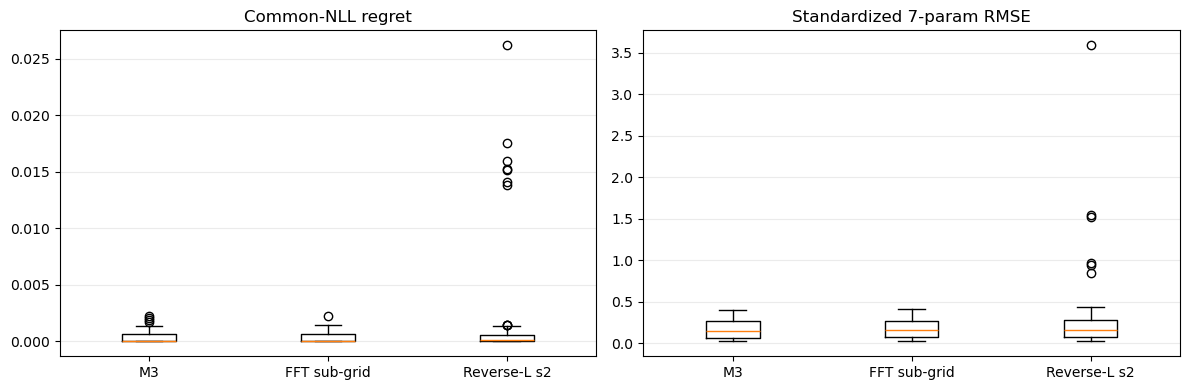

In [5]:
display(paired.round(6))

metrics = ['common_nll_regret','final_standardized_rmse_7param']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(axes, metrics, ['Common-NLL regret', 'Standardized 7-param RMSE']):
    data = [full.loc[full.method.eq(m), metric].to_numpy() for m in ['M3_empirical','M3_fft_subgrid','M3_reverseL_s2']]
    ax.boxplot(data, labels=['M3','FFT sub-grid','Reverse-L s2'], showfliers=True)
    ax.set_title(title); ax.grid(alpha=.25, axis='y')
fig.tight_layout(); plt.show()

## Replicate variance of final parameters

For every direction-speed-nuisance cell, variance is computed across its five independent replicates. Positive parameters use $\log(\hat\theta/\theta_0)$ and advection uses $(\hat v-v_0)/||v_0||$. The reported mean is the trace of the standardized covariance divided by seven.

,method,nuisance_scenario,mean_standardized_variance,median_standardized_variance,max_standardized_variance
0,M3_empirical,long_time_low_nugget,0.013259,0.011518,0.033471
1,M3_empirical,oracle_start,0.009803,0.010315,0.017390
2,M3_empirical,short_time_high_nugget,0.023272,0.024630,0.036685
3,M3_fft_subgrid,long_time_low_nugget,0.010478,0.009874,0.020304
4,M3_fft_subgrid,oracle_start,0.009182,0.009894,0.015842
5,M3_fft_subgrid,short_time_high_nugget,0.025011,0.025721,0.041225
6,M3_reverseL_s2,long_time_low_nugget,0.444079,0.014146,2.494526
7,M3_reverseL_s2,oracle_start,0.009064,0.009356,0.015121
8,M3_reverseL_s2,short_time_high_nugget,0.027643,0.032276,0.042161


,sigmasq,range_lat,range_lon,range_time,nugget,advec_lat,advec_lon
method,,,,,,,
M3_empirical,0.012082,0.022883,0.020218,0.025259,0.020542,0.001598,0.005531
M3_fft_subgrid,0.012223,0.021115,0.019991,0.023013,0.019961,0.001914,0.006016
M3_reverseL_s2,0.012852,0.024912,0.022965,0.042042,0.021799,0.576123,0.421139


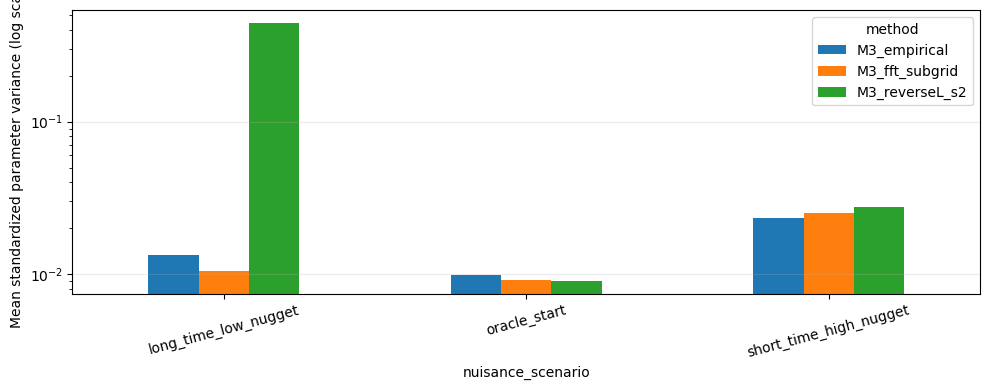

In [6]:
var_summary = (var_detail.groupby(['method','nuisance_scenario'], as_index=False)
    .agg(mean_standardized_variance=('mean_standardized_parameter_variance','mean'),
         median_standardized_variance=('mean_standardized_parameter_variance','median'),
         max_standardized_variance=('mean_standardized_parameter_variance','max')))
display(var_summary.round(6))

positive = ['sigmasq','range_lat','range_lon','range_time','nugget']
advection = ['advec_lat','advec_lon']
vrows = []
for (method, nuisance, truth_id), g in full.groupby(['method','nuisance_scenario','truth_id']):
    speed = g.true_advec_norm.iloc[0]
    row = {'method': method, 'nuisance_scenario': nuisance, 'truth_id': truth_id}
    for k in positive:
        row[k] = np.var(np.log(g[f'est_{k}'].to_numpy()/g[f'true_{k}'].to_numpy()), ddof=1)
    for k in advection:
        row[k] = np.var((g[f'est_{k}'].to_numpy()-g[f'true_{k}'].to_numpy())/speed, ddof=1)
    vrows.append(row)
var_by_parameter = pd.DataFrame(vrows).groupby('method')[positive+advection].mean()
display(var_by_parameter.round(6))
ax = var_summary.pivot(index='nuisance_scenario', columns='method', values='mean_standardized_variance').plot.bar(figsize=(10,4), logy=True)
ax.set_ylabel('Mean standardized parameter variance (log scale)'); ax.grid(alpha=.25, axis='y')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

## Tail failures and direction-speed interaction

In [7]:
tail_cols = ['dataset_id','nuisance_scenario','method','seed_lat','seed_lon','est_advec_lat','est_advec_lon',
             'common_nll_regret','final_standardized_rmse_7param','final_seed_error_euclid','final_grad_inf']
tails = full.loc[full.local_optimum_failure | full.parameter_failure, tail_cols].sort_values('common_nll_regret', ascending=False)
display(tails.round(6))

direction = (full.groupby(['method','speed_label','direction'], as_index=False)
    .agg(mean_nll_regret=('common_nll_regret','mean'), mean_parameter_error=('final_standardized_rmse_7param','mean'),
         local_failure_rate=('local_optimum_failure','mean')))
display(direction.round(5))

,dataset_id,nuisance_scenario,method,seed_lat,seed_lon,est_advec_lat,est_advec_lon,common_nll_regret,final_standardized_rmse_7param,final_seed_error_euclid,final_grad_inf
196,fast_NE_rep01,long_time_low_nugget,M3_reverseL_s2,-0.092945,0.206238,0.205501,0.218239,0.026198,0.362895,0.126820,0.009509
188,fast_NE_rep00,long_time_low_nugget,M3_reverseL_s2,0.012970,0.164531,0.580307,0.331629,0.017544,0.939118,0.517333,0.000001
350,fast_SE_rep03,long_time_low_nugget,M3_reverseL_s2,-0.045408,0.177936,-0.473706,0.446072,0.015911,0.845100,0.464280,0.000016
6,slow_NE_rep00,long_time_low_nugget,M3_reverseL_s2,0.009702,0.086374,0.383905,0.358696,0.015230,1.524079,0.430342,0.000173
339,fast_SE_rep02,long_time_low_nugget,M3_reverseL_s2,-0.039979,0.179172,-0.549393,0.436764,0.015154,0.963176,0.525725,0.000008
204,fast_NE_rep02,long_time_low_nugget,M3_reverseL_s2,0.659657,-0.011595,1.688360,-1.061814,0.014073,3.589333,2.044259,0.000304
25,slow_NE_rep02,long_time_low_nugget,M3_reverseL_s2,-0.003443,0.070278,0.333056,0.422574,0.013807,1.547870,0.435816,0.000302
35,slow_NE_rep03,long_time_low_nugget,M3_fft_subgrid,0.038878,0.120410,0.054529,0.122876,0.002220,0.285465,0.027100,0.046074
186,fast_NE_rep00,long_time_low_nugget,M3_empirical,0.088000,0.189000,0.065944,0.180549,0.002210,0.283866,0.023998,0.042407
296,fast_SW_rep02,long_time_low_nugget,M3_empirical,-0.088000,-0.189000,-0.054009,-0.190198,0.002062,0.313941,0.027778,0.032014


,method,speed_label,direction,mean_nll_regret,mean_parameter_error,local_failure_rate
0,M3_empirical,fast,NE,0.00044,0.15041,0.06667
1,M3_empirical,fast,NW,0.00029,0.16634,0.00000
2,M3_empirical,fast,SE,0.00027,0.10362,0.00000
3,M3_empirical,fast,SW,0.00059,0.18466,0.06667
4,M3_empirical,slow,NE,0.00020,0.19003,0.00000
5,M3_empirical,slow,NW,0.00039,0.20945,0.00000
6,M3_empirical,slow,SE,0.00026,0.14736,0.00000
7,M3_empirical,slow,SW,0.00033,0.21066,0.00000
8,M3_fft_subgrid,fast,NE,0.00025,0.13022,0.00000
9,M3_fft_subgrid,fast,NW,0.00024,0.15420,0.00000


## Interpretation and next algorithm

1. **M3 remains a valid empirical baseline.** It found the correct quadrant in all 40 fields and had mean seed error 0.0221 degree/hour.
2. **FFT sub-grid is the preferred production initializer.** Its mean seed error was 0.01265, versus 0.02214 for M3, and its mean seed cost was 0.0083 s versus 0.0939 s. After the short full fit, however, paired differences from M3 were essentially zero: common-NLL regret difference $-1.7\times10^{-5}$ (95% clustered bootstrap CI $[-8.4\times10^{-5},4.9\times10^{-5}]$) and parameter-error difference 0.00093 (CI $[-0.00882,0.01043]$). Thus it is a clear computational/seed improvement, not evidence of a different final estimator.
3. **Unconstrained Reverse-L stride-2 is not robust enough.** Relative to M3, mean common-NLL regret increased by 0.00094 (CI [0.00032, 0.00166]), standardized parameter error by 0.06495 (CI [0.00790, 0.13594]), and end-to-end time by 0.644 s. Under oracle nuisance its variance was as good as FFT, but under long-time/low-nugget misspecification its mean standardized variance rose to 0.444, versus 0.0133 for M3 and 0.0105 for FFT. Seven of 40 runs in that scenario had a local-optimum failure and six had parameter RMSE above 0.5. Failures concentrated in slow/fast NE and fast SE.
4. **The strict gradient convergence statistic should not be confused with algorithm crashes.** All 360 runs were finite, while nearly all consumed the predeclared 20 function-evaluation budget. Oracle-start convergence was 87.5–90%; misspecified starts often needed more optimization. This is itself evidence that nuisance misspecification dominates short-budget convergence.

The next competitive method should therefore be **safeguarded, nuisance-ensemble Reverse-L**, not the current unconditional refinement: start from FFT sub-grid; score each proposed step under all three nuisance anchors (or at least short/long temporal-range anchors); restrict motion to a grid-scaled trust region around the FFT seed; require improvement for the robust aggregate score; otherwise keep the FFT seed. The trust radius and acceptance threshold must be fixed in advance on a separate calibration set, then evaluated on new replicates to avoid post-hoc tuning.

## Reproducibility

Benchmark script: `synthetic_initializer_factorial_robustness_corridor432_083126.py`. Raw and summarized outputs are under `outputs/summer_26/synthetic_initializer_factorial_robustness_corridor432_083126/`. The full benchmark used CPU and took 62.38 minutes including 2,000 clustered bootstrap replicates.